# Simulation of CCD images

With the goal of making it easier to generate simulated astronomical images, **teareduce** provides a class called `SimulateCCDExposure` that simplifies this task.

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from rich import print
import teareduce as tea

In [2]:
help(tea.SimulateCCDExposure)

Help on class SimulateCCDExposure in module teareduce.simulateccdexposure:

class SimulateCCDExposure(builtins.object)
 |  SimulateCCDExposure(
 |      naxis1=None,
 |      naxis2=None,
 |      bitpix=None,
 |      bias=<Quantity nan adu>,
 |      gain=<Quantity nan electron / adu>,
 |      readout_noise=<Quantity nan adu>,
 |      dark=<Quantity nan adu>,
 |      flatfield=nan,
 |      data_model=<Quantity nan adu>,
 |      seed=None
 |  )
 |
 |  Simulated image generator from first principles.
 |
 |  CCD exposures are simulated making use of basic CCD parameters,
 |  such as gain, readout noise, bias, dark and flat field.
 |  A data model can also be employed to simulate more realistic
 |  CCD exposures.
 |
 |  The saturated pixels in 'data_model' are returned as 2**bitpix - 1
 |  in the simulated image (for instance, 65535 when bitpix=16).
 |
 |  By initializing the seed of the random number generator
 |  when instantiating this class, there is in principle no need to
 |  use anothe

## Simple usage

Define image basic parameters (dimensions, BITPIX)

In [3]:
naxis1, naxis2 = 5, 5
bitpix = 16

Each instance of the `SimulateCCDExposure` class becomes an image generator with the specified properties.

In [4]:
generator = tea.SimulateCCDExposure(
    naxis1=naxis1,
    naxis2=naxis2,
    bitpix=bitpix
)

The generator we have just created contains information about the image dimensions and the BITPIX value, but there are still many attributes left undefined:

In [5]:
generator

SimulateCCDExposure(
    naxis1=5,
    naxis2=5,
    bitpix=16,
    bias=<Quantity [[nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan]] adu>,
    gain=<Quantity [[nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan]] electron / adu>,
    readout_noise=<Quantity [[nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan]] adu>,
    dark=<Quantity [[nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan]] adu>,
    flatfield=array([[nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, n

If we try to use the generator as defined so far to create a bias image, we should encounter an error message.

In [6]:
try:
    exposure_bias = generator.run(imgtype='bias')
except Exception as e:
    print(f"[bold red]ERROR: exception ocurred:[/bold red] {type(e).__name__}: {e}")

ERROR: exception ocurred: ValueError: The parameter 'bias' contains NaN

We can see, then, that to generate a BIAS image we need to construct a generator that includes this information. For example, we can define the generator by specifying, in addition to the dimensions and BITPIX, the bias signal and the readout noise.

In [7]:
generator = tea.SimulateCCDExposure(
    naxis1=naxis1, naxis2=naxis2, bitpix=bitpix,
    bias=np.ones((naxis2, naxis1))*1000*u.adu,
    readout_noise=5*u.adu
)

generator

SimulateCCDExposure(
    naxis1=5,
    naxis2=5,
    bitpix=16,
    bias=<Quantity [[1000., 1000., 1000., 1000., 1000.],
           [1000., 1000., 1000., 1000., 1000.],
           [1000., 1000., 1000., 1000., 1000.],
           [1000., 1000., 1000., 1000., 1000.],
           [1000., 1000., 1000., 1000., 1000.]] adu>,
    gain=<Quantity [[nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan]] electron / adu>,
    readout_noise=<Quantity [[5., 5., 5., 5., 5.],
           [5., 5., 5., 5., 5.],
           [5., 5., 5., 5., 5.],
           [5., 5., 5., 5., 5.],
           [5., 5., 5., 5., 5.]] adu>,
    dark=<Quantity [[nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan]] adu>,
    flatfield=array([[nan, nan, nan, nan, nan],
       [nan, nan, nan, 

We can then generate a simulated BIAS image using the method `run(imgtype='bias')`:


In [8]:
exposure_bias = generator.run(imgtype='bias')

The result is an object of type `SimulatedCCDResult`, which contains not only the simulated image but also all the information used to define the generator that was employed.

In [9]:
type(exposure_bias)

teareduce.simulateccdexposure.SimulatedCCDResult

In [10]:
exposure_bias

SimulatedCCDResult(
    data=array([[1009.08345549, 1009.30307399,  996.35680948, 1002.97506678,
        1002.48495059],
       [ 987.47442477, 1009.80498846,  998.20773175,  997.40568745,
        1004.9558403 ],
       [ 999.89148449, 1002.64119889,  996.7542597 , 1000.2985487 ,
        1000.53156136],
       [1000.04671402, 1001.0847499 , 1006.98044893,  998.86433684,
        1005.1710229 ],
       [1007.00260707,  993.63855628, 1010.14965574, 1007.8482142 ,
         994.04411693]]),
    unit=Unit("adu"),
    imgtype='bias',
    method='poisson',
    origin=SimulateCCDExposure(
    naxis1=5,
    naxis2=5,
    bitpix=16,
    bias=<Quantity [[1000., 1000., 1000., 1000., 1000.],
           [1000., 1000., 1000., 1000., 1000.],
           [1000., 1000., 1000., 1000., 1000.],
           [1000., 1000., 1000., 1000., 1000.],
           [1000., 1000., 1000., 1000., 1000.]] adu>,
    gain=<Quantity [[nan, nan, nan, nan, nan],
           [nan, nan, nan, nan, nan],
           [nan, nan, nan, nan

The `.data` attribute contains the NumPy array with the simulated image.

In [11]:
type(exposure_bias.data)

numpy.ndarray

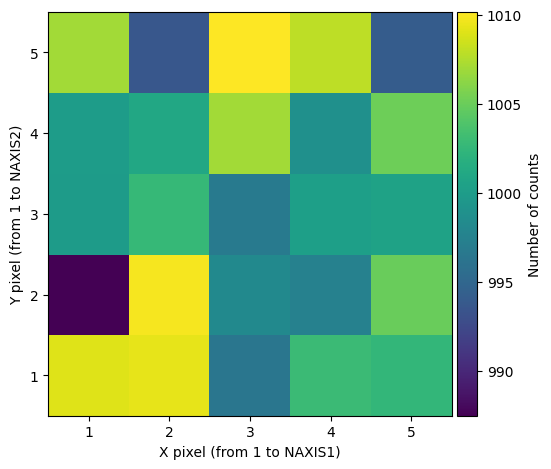

In [12]:
tea.imshowme(exposure_bias.data, ds9mode=True)
plt.tight_layout()

**Documentation pending update from this point**